In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn requests tf2onnx skl2onnx onnx

Dataset extracted to 'mhealth_data/'
Loading subject files...

--- Starting EDA ---
Total missing values: 0


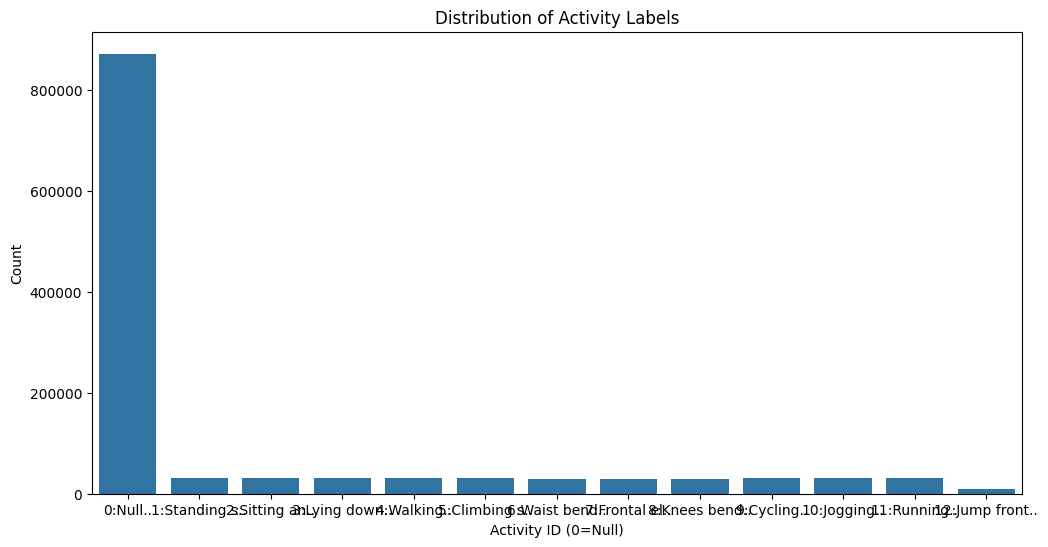

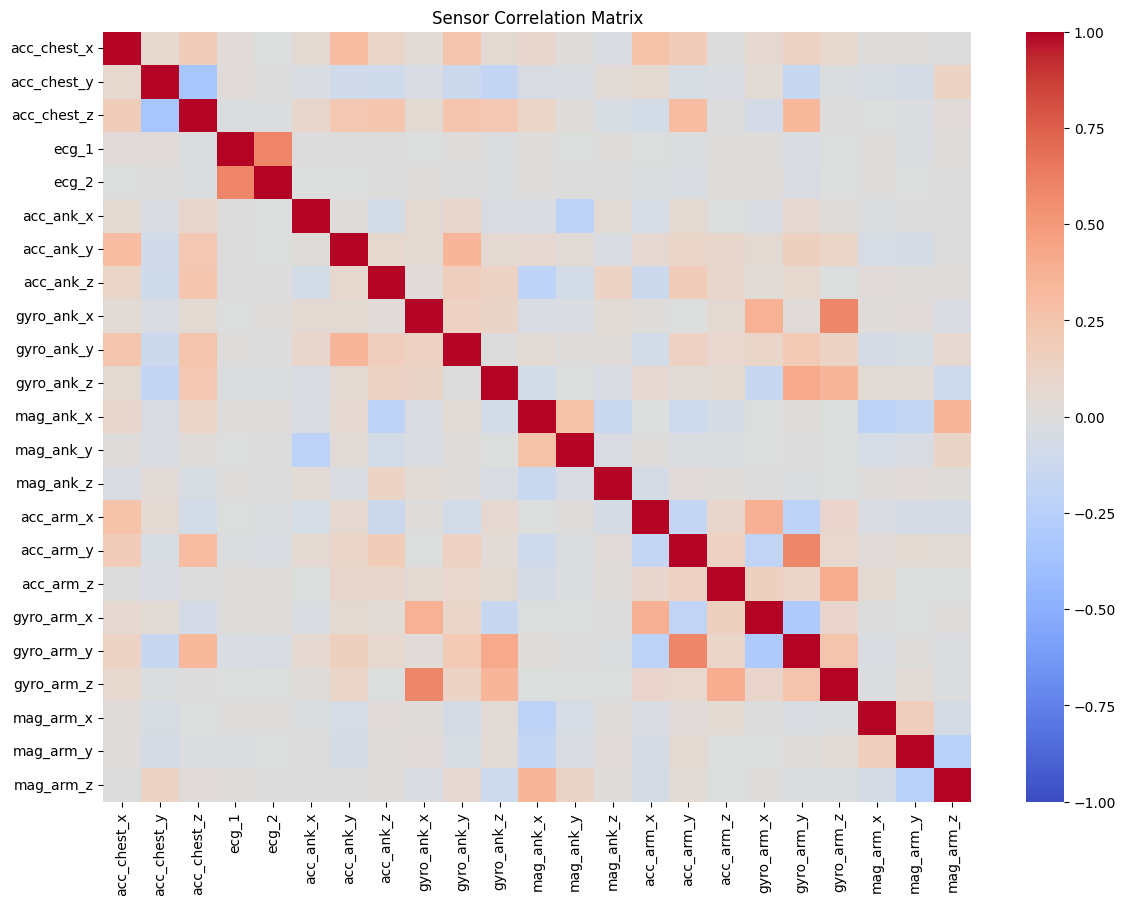

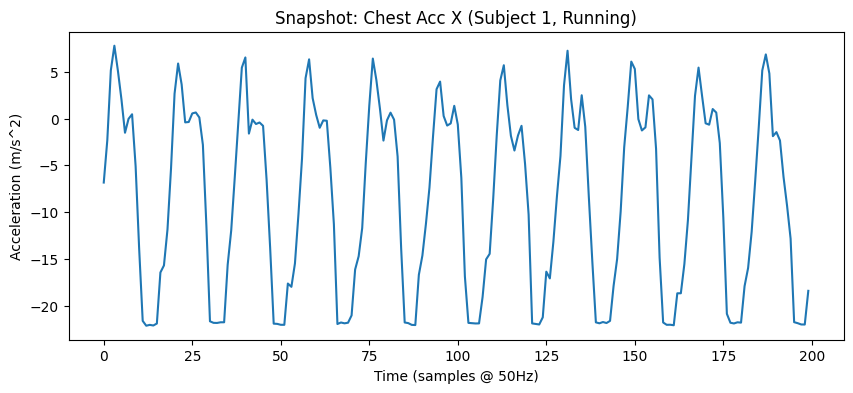


--- Performing Transformations ---
Data shape after removing Null class (0): (343195, 25)
Generated 1405 sliding windows (Subject 1 demo).
Window shape: (1405, 50, 3)

       DATASET FINDINGS SUMMARY
1. DATA VOLUME
   - Total Samples: 1,215,745
   - Total Subjects: 10
   - Sampling Rate: 50 Hz (approx 6.75 hours of data)

2. DATA QUALITY
   - Quality: No missing values found in raw data.

3. ACTIVITY DISTRIBUTION
   - Null Class (0): 71.8% of data (Transitions/Non-activity)
   - Valid Activities: 343,195 samples remaining after cleaning.

4. SENSOR CHANNELS
   - Total Columns: 25
   - Modalities: Acceleration, Gyroscope, Magnetometer, ECG
   - Body Locations: Chest, Left Ankle, Right Lower Arm

5. RECOMMENDATIONS
   - Preprocessing: The 'Null' class (0) dominates the dataset and should
     be removed for training specific activity classifiers.
   - Normalization: Sensor values have different ranges (e.g., ECG vs Acc);
     StandardScaler is recommended before Machine Learning.


In [2]:
import requests
import zipfile
import io
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
DATASET_URL = 'https://archive.ics.uci.edu/static/public/319/mhealth+dataset.zip'
EXTRACT_DIR = 'mhealth_data'
SUBJECTS = [f'mHealth_subject{i}.log' for i in range(1, 11)]

# Column Definitions based on UCI Documentation
# 3 Acc (Chest), 2 ECG (Chest), 3 Acc (LA), 3 Gyro (LA), 3 Mag (LA),
# 3 Acc (RLA), 3 Gyro (RLA), 3 Mag (RLA), 1 Label
COLUMN_NAMES = [
    'acc_chest_x', 'acc_chest_y', 'acc_chest_z',
    'ecg_1', 'ecg_2',
    'acc_ank_x', 'acc_ank_y', 'acc_ank_z',
    'gyro_ank_x', 'gyro_ank_y', 'gyro_ank_z',
    'mag_ank_x', 'mag_ank_y', 'mag_ank_z',
    'acc_arm_x', 'acc_arm_y', 'acc_arm_z',
    'gyro_arm_x', 'gyro_arm_y', 'gyro_arm_z',
    'mag_arm_x', 'mag_arm_y', 'mag_arm_z',
    'activity_label'
]

ACTIVITY_MAP = {
    0: 'Null', 1: 'Standing still', 2: 'Sitting and relaxing', 3: 'Lying down',
    4: 'Walking', 5: 'Climbing stairs', 6: 'Waist bends forward',
    7: 'Frontal elevation of arms', 8: 'Knees bending', 9: 'Cycling',
    10: 'Jogging', 11: 'Running', 12: 'Jump front & back'
}

def download_and_extract_data():
    """Downloads the dataset zip and extracts it."""
    print(f"Downloading dataset from {DATASET_URL}...")
    try:
        r = requests.get(DATASET_URL)
        r.raise_for_status()
        z = zipfile.ZipFile(io.BytesIO(r.content))
        z.extractall(EXTRACT_DIR)
        print(f"Dataset extracted to '{EXTRACT_DIR}/'")
    except Exception as e:
        print(f"Error downloading data: {e}")
        exit()

def load_data():
    """Loads all subject log files into a single DataFrame."""
    all_data = []
    # The zip usually contains a subfolder 'MHEALTHDATASET'. Check path.
    base_path = os.path.join(EXTRACT_DIR, 'MHEALTHDATASET')

    # Fallback if zip structure is flat
    if not os.path.exists(base_path):
        base_path = EXTRACT_DIR

    print("Loading subject files...")
    for i, filename in enumerate(SUBJECTS, start=1):
        file_path = os.path.join(base_path, filename)
        if os.path.exists(file_path):
            # Read tab/space separated file
            df = pd.read_csv(file_path, sep='\t', header=None, names=COLUMN_NAMES)
            df['subject_id'] = i  # Add subject ID column
            all_data.append(df)
        else:
            print(f"Warning: {filename} not found.")

    if not all_data:
        print("No data loaded. Check extract directory.")
        exit()

    return pd.concat(all_data, ignore_index=True)

def perform_eda(df):
    """Performs Exploratory Data Analysis and generates plots."""
    print("\n--- Starting EDA ---")

    # 1. Missing Values
    null_counts = df.isnull().sum().sum()
    print(f"Total missing values: {null_counts}")

    # 2. Class Distribution Plot
    plt.figure(figsize=(12, 6))
    sns.countplot(x='activity_label', data=df)
    plt.title('Distribution of Activity Labels')
    plt.xlabel('Activity ID (0=Null)')
    plt.ylabel('Count')
    plt.xticks(ticks=range(13), labels=[f"{k}:{v[:10]}.." for k,v in ACTIVITY_MAP.items()])
    plt.show()

    # 3. Correlation Matrix (Sensor Data Only)
    sensor_cols = [c for c in COLUMN_NAMES if c != 'activity_label']
    corr = df[sensor_cols].corr()
    plt.figure(figsize=(14, 10))
    sns.heatmap(corr, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title('Sensor Correlation Matrix')
    plt.show()

    # 4. Time Series Snapshot (e.g., Acc Chest X for Subject 1, Activity 11-Running)
    subset = df[(df['subject_id'] == 1) & (df['activity_label'] == 11)].iloc[:200]
    if not subset.empty:
        plt.figure(figsize=(10, 4))
        plt.plot(subset['acc_chest_x'].reset_index(drop=True))
        plt.title('Snapshot: Chest Acc X (Subject 1, Running)')
        plt.xlabel('Time (samples @ 50Hz)')
        plt.ylabel('Acceleration (m/s^2)')
        plt.show()

def transform_data(df):
    """Performs transformations: filtering and sliding windows."""
    print("\n--- Performing Transformations ---")

    # Transformation 1: Filter out 'Null' class (Label 0)
    # The 'Null' class usually represents transition periods or non-scripted movements.
    df_clean = df[df['activity_label'] != 0].copy()
    print(f"Data shape after removing Null class (0): {df_clean.shape}")

    # Transformation 2: Sliding Window (Simple Example)
    # Create windows of 50 samples (1 second) with 50% overlap
    window_size = 50
    step_size = 25

    windows = []
    labels = []

    # Use a small subset for demonstration speed, or full df_clean for real use
    # Looping through one subject/activity to demonstrate
    demo_subset = df_clean[df_clean['subject_id'] == 1]

    for start in range(0, len(demo_subset) - window_size, step_size):
        end = start + window_size
        # Extract window
        window = demo_subset.iloc[start:end][['acc_chest_x', 'acc_chest_y', 'acc_chest_z']].values
        # Take the mode label for this window
        label = demo_subset.iloc[start:end]['activity_label'].mode()[0]
        windows.append(window)
        labels.append(label)

    print(f"Generated {len(windows)} sliding windows (Subject 1 demo).")
    print(f"Window shape: {np.array(windows).shape}")

    return df_clean

def generate_summary(df, df_clean):
    """Prints a text summary of findings."""
    print("\n" + "="*40)
    print("       DATASET FINDINGS SUMMARY")
    print("="*40)

    n_samples = len(df)
    n_subjects = df['subject_id'].nunique()

    print(f"1. DATA VOLUME")
    print(f"   - Total Samples: {n_samples:,}")
    print(f"   - Total Subjects: {n_subjects}")
    print(f"   - Sampling Rate: 50 Hz (approx {n_samples/50/60/60:.2f} hours of data)")

    print(f"\n2. DATA QUALITY")
    if df.isnull().values.any():
        print("   - Issues: Missing values detected (imputation needed).")
    else:
        print("   - Quality: No missing values found in raw data.")

    print(f"\n3. ACTIVITY DISTRIBUTION")
    counts = df['activity_label'].value_counts()
    null_percent = (counts.get(0, 0) / n_samples) * 100
    print(f"   - Null Class (0): {null_percent:.1f}% of data (Transitions/Non-activity)")
    print(f"   - Valid Activities: {len(df_clean):,} samples remaining after cleaning.")

    print(f"\n4. SENSOR CHANNELS")
    print(f"   - Total Columns: {len(df.columns)}")
    print("   - Modalities: Acceleration, Gyroscope, Magnetometer, ECG")
    print("   - Body Locations: Chest, Left Ankle, Right Lower Arm")

    print(f"\n5. RECOMMENDATIONS")
    print("   - Preprocessing: The 'Null' class (0) dominates the dataset and should")
    print("     be removed for training specific activity classifiers.")
    print("   - Normalization: Sensor values have different ranges (e.g., ECG vs Acc);")
    print("     StandardScaler is recommended before Machine Learning.")
    print("="*40)

# --- Main Execution ---
if __name__ == "__main__":
    download_and_extract_data()
    df = load_data()
    perform_eda(df)
    df_clean = transform_data(df)
    generate_summary(df, df_clean)

In [3]:
import os
import pandas as pd
import numpy as np
from scipy import stats
import requests
import zipfile
import io

# --- Constants ---
DATASET_URL = 'https://archive.ics.uci.edu/static/public/319/mhealth+dataset.zip'
EXTRACT_DIR = 'mhealth_data'
WINDOW_SIZE = 100  # 2 seconds
STEP_SIZE = 50     # 50% overlap

def get_mhealth_data():
    """Downloads (if needed) and processes mHealth data into X (windows) and y (labels)."""

    # 1. Download
    if not os.path.exists(EXTRACT_DIR):
        print("Downloading dataset...")
        r = requests.get(DATASET_URL)
        z = zipfile.ZipFile(io.BytesIO(r.content))
        z.extractall(EXTRACT_DIR)

    # 2. Load
    subjects = [f'mHealth_subject{i}.log' for i in range(1, 11)]
    data_list = []
    base_path = os.path.join(EXTRACT_DIR, 'MHEALTHDATASET')
    if not os.path.exists(base_path): base_path = EXTRACT_DIR

    print("Loading and processing log files...")
    for filename in subjects:
        filepath = os.path.join(base_path, filename)
        if os.path.exists(filepath):
            # 23 columns
            df = pd.read_csv(filepath, sep='\t', header=None)
            data_list.append(df)

    raw_data = pd.concat(data_list, ignore_index=True)

    # 3. Clean: Remove Null Class (0)
    # Column 23 is the label
    raw_data = raw_data[raw_data[23] != 0]

    X_data = raw_data.iloc[:, :23].values
    y_data = raw_data.iloc[:, 23].values

    # 4. Sliding Window
    X_frames, y_frames = [], []
    for i in range(0, len(X_data) - WINDOW_SIZE, STEP_SIZE):
        X_frames.append(X_data[i: i + WINDOW_SIZE])
        # Label is the mode of the window
        y_frames.append(stats.mode(y_data[i: i + WINDOW_SIZE], keepdims=True)[0][0])

    X = np.array(X_frames)
    y = np.array(y_frames)

    # Remap labels to 0-11 range for training
    y = y - 1

    print(f"Data Loaded: X shape {X.shape}, y shape {y.shape}")
    return X, y

Loading and processing log files...
Data Loaded: X shape (6862, 100, 23), y shape (6862,)
Tuning XGBoost...
Fitting 3 folds for each of 5 candidates, totalling 15 fits


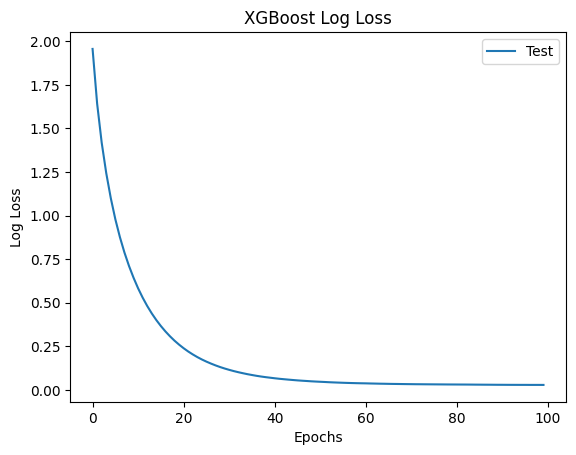

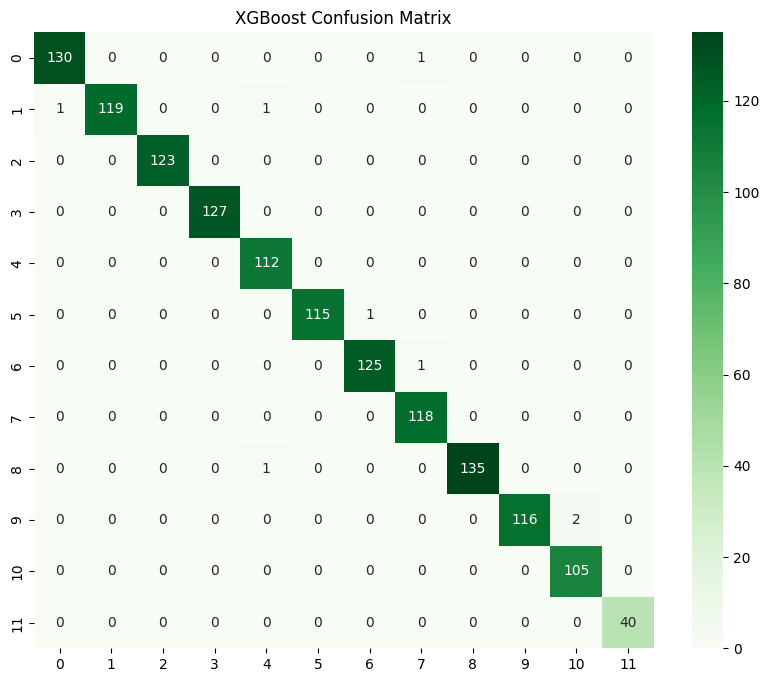

ValueError: could not convert string to float: '[8.76298E-2,8.999818E-2,8.9633815E-2,8.854072E-2,9.145564E-2,8.2528695E-2,8.416834E-2,8.5443616E-2,8.708326E-2,9.036254E-2,9.29131E-2,3.0242303E-2]'

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import onnxmltools
from onnxmltools.convert.common.data_types import FloatTensorType

# 1. Load & Prep
X_raw, y = get_mhealth_data()
X_features = np.hstack([np.mean(X_raw, axis=1), np.std(X_raw, axis=1)])
X_train, X_test, y_train, y_test = train_test_split(X_features, y, test_size=0.2, random_state=42)

# 2. Hyperparameter Tuning
print("Tuning XGBoost...")
param_dist = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.9]
}
clf = xgb.XGBClassifier(objective='multi:softmax', num_class=12, eval_metric='mlogloss')
search = RandomizedSearchCV(clf, param_distributions=param_dist, n_iter=5, cv=3, verbose=1, n_jobs=-1)
search.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

best_model = search.best_estimator_

# 3. Metrics & Plots
results = best_model.evals_result()
epochs = len(results['validation_0']['mlogloss'])
x_axis = range(0, epochs)

# Loss Graph
plt.figure()
plt.plot(x_axis, results['validation_0']['mlogloss'], label='Test')
plt.title('XGBoost Log Loss')
plt.xlabel('Epochs')
plt.ylabel('Log Loss')
plt.legend()
plt.savefig('xgb_loss_graph.png')
plt.show()

# Confusion Matrix
y_pred = best_model.predict(X_test)
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title('XGBoost Confusion Matrix')
plt.savefig('xgb_confusion_matrix.png')
plt.show()

# 4. Saving
joblib.dump(best_model, 'best_xgb_model.joblib')

# ONNX Conversion
initial_type = [('float_input', FloatTensorType([None, X_features.shape[1]]))]
onnx_model = onnxmltools.convert_xgboost(best_model, initial_types=initial_type)
with open("best_xgb_model.onnx", "wb") as f:
    f.write(onnx_model.SerializeToString())

print("Saved: best_xgb_model.joblib, best_xgb_model.onnx")

In [8]:
pip install onnxmltools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 352.5/352.5 kB 11.4 MB/s eta 0:00:00
